# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [160]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [161]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
### CODE HERE ###
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [162]:
# Separate features and target, remap so malignant = 1
### CODE HERE ###
##Assign target to df and remap so malignant = 1
df['target'] = data.target

df['target'] = 1 - df['target']
X = df.drop (columns='target')
y = df['target']

df.head()



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [163]:
# Display first 5 rows
### CODE HERE ###
print("Head : \n", df.head())


Head : 
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0    

In [164]:
# Check shape, data types, and missing values
### CODE HERE ###
print("Shape : \n", df.shape)
print("Info : \n", df.info())
print("Missing values : \n", df.isnull().sum())

Shape : 
 (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [165]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
### CODE HERE ###
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


Class distribution : 
 target
0    357
1    212
Name: count, dtype: int64


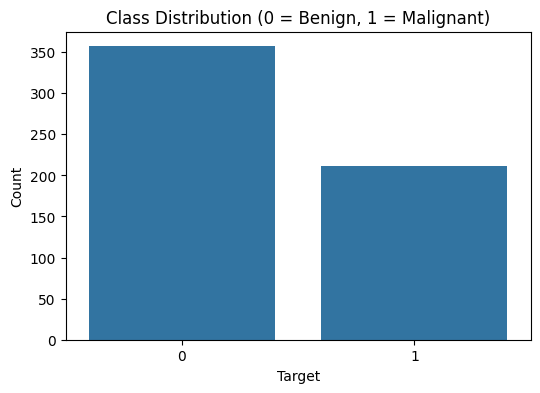

In [166]:
# Class distribution after remapping
### CODE HERE ###
print("Class distribution : \n", y.value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Class Distribution (0 = Benign, 1 = Malignant)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


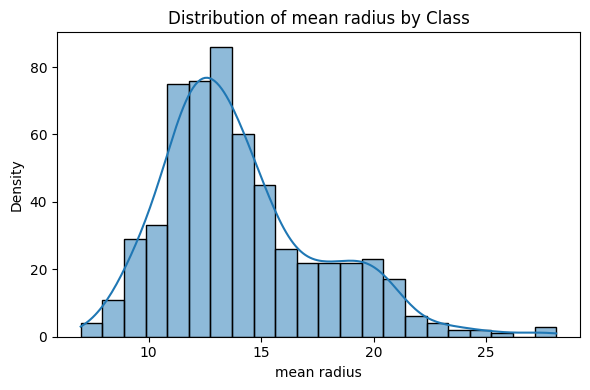

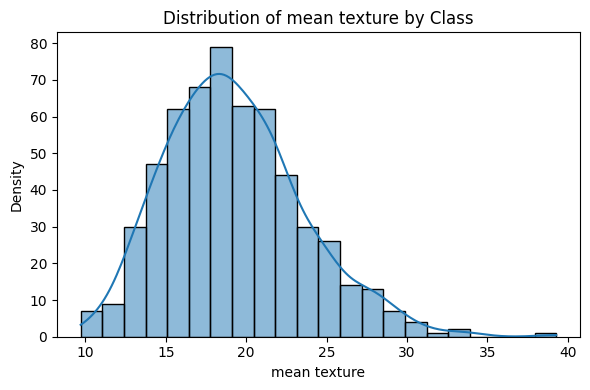

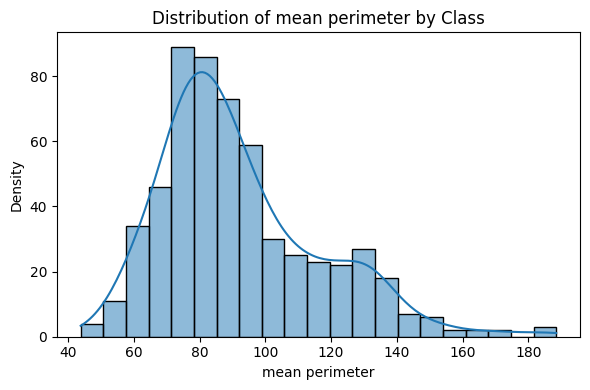

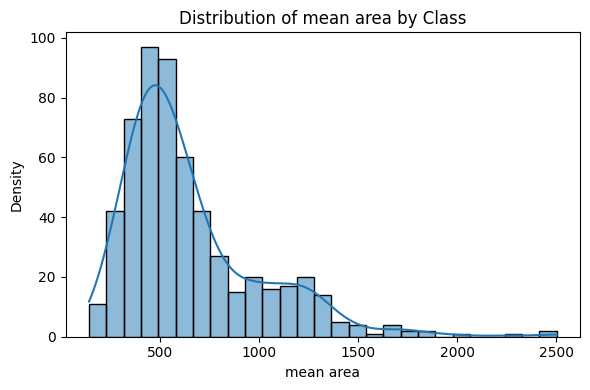

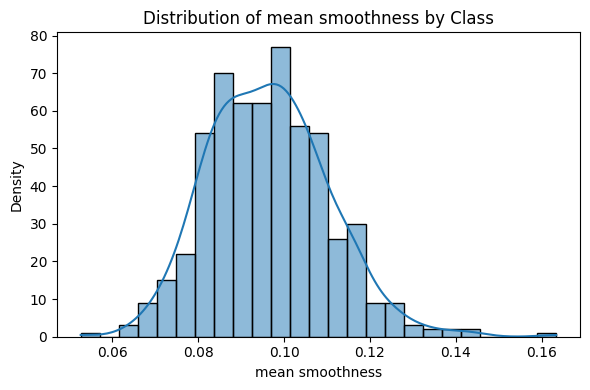

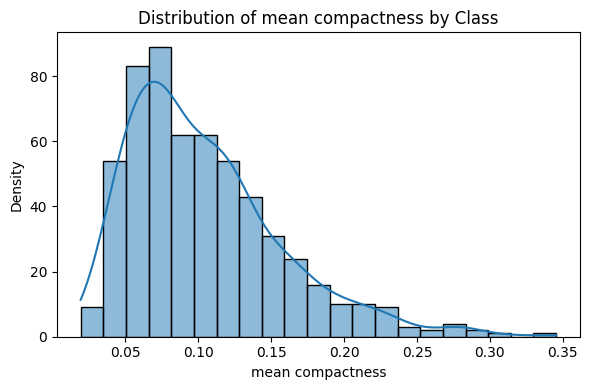

In [167]:
# Feature distributions for 6 selected features, coloured by class
### CODE HERE ###
features = data.feature_names[:6]  # Select first 6 features for visualization
for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. 

2. ***your answer here***

3. ***your answer here***

4. ***your answer here***


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [168]:
# Missing value audit
### CODE HERE ###
print("Missing values : \n", df.isnull().sum())

Missing values : 
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [169]:
# Stratified train-test split
### CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [170]:
# Feature scaling: fit on train only, transform both
### CODE HERE ###
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [171]:
# Confirm prepared data
### CODE HERE ###
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train distribution:
 target
0    250
1    148
Name: count, dtype: int64
y_test distribution:
 target
0    107
1     64
Name: count, dtype: int64


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [172]:
# Helper function. Use this to evaluate all models consistently.
### CODE HERE ###
def evaluate_model(y_true, y_pred):
    print("Accuracy:", f"{accuracy_score(y_true, y_pred):.4f}")
    print("Recall:", f"{recall_score(y_true, y_pred , average='macro'):.4f}")
    print("Precision:", f"{precision_score(y_true, y_pred , average='macro'):.4f}")
    print("F1 Score:", f"{f1_score(y_true, y_pred , average='macro'):.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [173]:
# Logistic Regression with GridSearchCV
### CODE HERE ###
lr = LogisticRegression(class_weight='balanced', random_state=42)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='recall')
grid_search_lr.fit(X_train_scaled, y_train)

print("Logistic Regression Best parameters:", grid_search_lr.best_params_)
print("Logistic Regression Best CV recall:", grid_search_lr.best_score_)

Logistic Regression Best parameters: {'C': 10}
Logistic Regression Best CV recall: 0.9388505747126438


In [174]:
# Evaluate LR on test set
### CODE HERE ###
best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
evaluate_model(y_test, y_pred_lr)
print('=' * 60)



Accuracy: 0.9708
Recall: 0.9641
Precision: 0.9736
F1 Score: 0.9685

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [175]:
# KNN with GridSearchCV
### CODE HERE ###
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9,11,15],
    'weights': ['uniform', 'distance']
}

grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='recall')


In [176]:
# Evaluate KNN on test set
### CODE HERE ###
grid_search_knn.fit(X_train_scaled, y_train)


print("KNN Best parameters:", grid_search_knn.best_params_)
print("KNN Best CV recall:", grid_search_knn.best_score_)

best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
evaluate_model(y_test, y_pred_knn)

print('=' * 60)

KNN Best parameters: {'n_neighbors': 7, 'weights': 'uniform'}
KNN Best CV recall: 0.925287356321839
Accuracy: 0.9649
Recall: 0.9531
Precision: 0.9735
F1 Score: 0.9618

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [177]:
# Decision Tree with GridSearchCV
### CODE HERE ###
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=5, scoring='recall')

In [178]:
# Evaluate Decision Tree on test set
### CODE HERE ###
grid_search_dt.fit(X_train_scaled, y_train)

print("Decision Tree Best parameters:", grid_search_dt.best_params_)
print("Decision Tree Best CV recall:", grid_search_dt.best_score_)

best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
evaluate_model(y_test, y_pred_dt)
print('=' * 60)

Decision Tree Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree Best CV recall: 0.9319540229885057
Accuracy: 0.9064
Recall: 0.8938
Precision: 0.9050
F1 Score: 0.8988

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       107
           1       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [179]:
# SVM with GridSearchCV
### CODE HERE ###
svm = SVC(class_weight='balanced', random_state=42 , probability=True)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, scoring='recall')

grid_search_svm.fit(X_train_scaled, y_train)
print("SVM Best parameters:", grid_search_svm.best_params_) 
print("SVM Best CV recall:", grid_search_svm.best_score_)

SVM Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Best CV recall: 0.9519540229885057


In [180]:
# Evaluate SVM on test set
### CODE HERE ###
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
evaluate_model(y_test, y_pred_svm)
print('=' * 60)

Accuracy: 0.9825
Recall: 0.9797
Precision: 0.9828
F1 Score: 0.9812

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       107
           1       0.98      0.97      0.98        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [181]:
# Comparison table for all 4 models
### CODE HERE ###
model_predictions = {
    "LogisticRegression" : y_pred_lr,
    "KNN" : y_pred_knn,
    "DecisionTree" : y_pred_dt,
    "SVM" : y_pred_svm
}

comparison_data = []

#calculating metrics for each model and storing in comparison_data
for model_name, y_pred in model_predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    false_negatives = cm[1][0]

    comparison_data.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1,
        "False Negatives": false_negatives
    })

    comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)   

                Model  Accuracy   Recall  Precision  F1 Score  False Negatives
0  LogisticRegression  0.970760  0.93750   0.983607  0.960000                4
1                 KNN  0.964912  0.90625   1.000000  0.950820                6
2        DecisionTree  0.906433  0.84375   0.900000  0.870968               10
3                 SVM  0.982456  0.96875   0.984127  0.976378                2


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


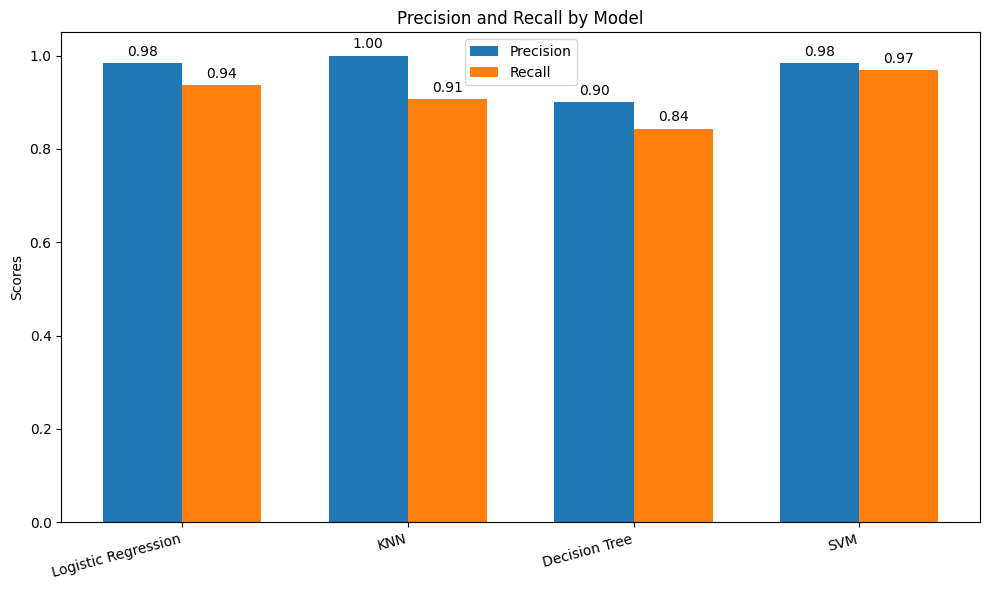

In [182]:
# Grouped bar chart: Recall and Precision
### CODE HERE ###
models = ["Logistic Regression", "KNN", "Decision Tree", "SVM"]

precision_scores = [0.983607,1.000000 ,0.900000,0.984127 ]
recall_scores = [0.93750,0.90625 ,0.84375,0.96875 ]

x = np.arange(len(models)) 
width = 0.35

fig,ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - width/2, precision_scores, width, label='Precision')
rects2 = ax.bar(x + width/2, recall_scores, width, label='Recall')

ax.set_ylabel('Scores')
ax.set_title('Precision and Recall by Model')
ax.set_xticks(x)
ax.set_xticklabels(models , rotation=15 , ha='right')
ax.legend()

ax.bar_label(rects1, padding=3 , fmt='%.2f')
ax.bar_label(rects2, padding=3 , fmt='%.2f')

fig.tight_layout()



### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [183]:
# Cross-validation stability for all 4 models
### CODE HERE ###
models = {
    "Logistic Regression": best_lr, 
    "KNN": best_knn,
    "Decision Tree": best_dt,   
    "SVM": best_svm
}

cv_results = {}

for model_name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='recall')

    cv_results[model_name] = {
        "Mean": scores.mean(),
        "Std Dev": scores.std()
    }

    print(f"{model_name} CV Recall: Mean={scores.mean():.4f}, Std Dev={scores.std():.4f}")
    print("-"*35)

Logistic Regression CV Recall: Mean=0.9389, Std Dev=0.0262
-----------------------------------
KNN CV Recall: Mean=0.9253, Std Dev=0.0736
-----------------------------------
Decision Tree CV Recall: Mean=0.9320, Std Dev=0.0485
-----------------------------------
SVM CV Recall: Mean=0.9520, Std Dev=0.0640
-----------------------------------


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


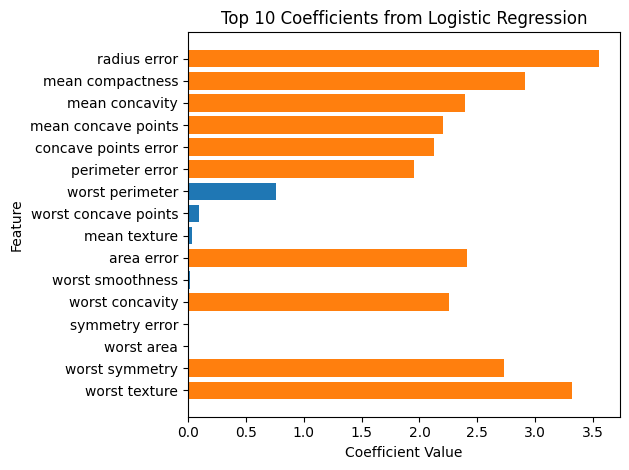

In [184]:
# Feature importance from Decision Tree
### CODE HERE ###
feature_importances = best_dt.feature_importances_

feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

sorted_importances = feature_importance_series.sort_values(ascending=True)[-10:]

plt.barh(sorted_importances.index, sorted_importances.values)
plt.title('Top 10 Feature Importances from Decision Tree')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()

#Logistic regression coefficients
### CODE HERE ###
coefficients = best_lr.coef_[0]
coef_series = pd.Series(coefficients, index=X_train.columns)

sorted_coefficients = coef_series.abs().sort_values(ascending=True)[-10:]

plt.barh(sorted_coefficients.index, sorted_coefficients.values)
plt.title('Top 10 Coefficients from Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()

## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


Optimal threshold for recall >= 0.95: 0.0004


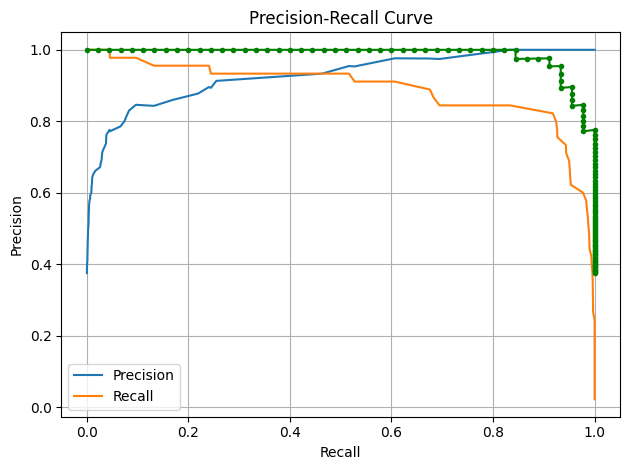

In [185]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
### CODE HERE ###
X_train_sub , X_val, y_train_sub, y_val = train_test_split(X_train_scaled, y_train, test_size=0.3, random_state=42, stratify=y_train)

# Step 2: Retrain best model (SVM) on inner training set
### CODE HERE ###
best_model = best_svm
best_model.fit(X_train_sub, y_train_sub)

# Step 3: Get predicted probabilities on validation set
### CODE HERE ###
y_val_probs = best_model.predict_proba(X_val)[:, 1]

# Step 4: Plot precision-recall curve
### CODE HERE ###
precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()

plt.plot(recall,precision,marker='.',color='green',label = 'Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.tight_layout()

# Step 5: Find threshold where recall >= 0.95
### CODE HERE ###
valid_thresholds = np.where(recall >= 0.95)[0]
if len(valid_thresholds) > 0:
    optimal_threshold = thresholds[valid_thresholds[0]]
    print(f"Optimal threshold for recall >= 0.95: {optimal_threshold:.4f}")
else:
    best_threshold = None
    print("No threshold found that achieves recall >= 0.95")

### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. I recommend SVM model for breast cancer because it achieves good recall : 0.96875 ,false negatives : 2 and cross validation stability of Mean=0.9520, Std Dev=0.0640

2. It produced 2 false positives on test set . Even though every false positives poses risk , model achieved 96% recall rate with only 2 false negatives

3. *


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [186]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
### CODE HERE ###
df_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df_wine['target'] = wine_data.target
df_wine.head()

X_wine = df_wine.drop(columns='target')
y_wine = df_wine['target']

print("Wine dataset loaded")
print(df_wine.head())

Wine dataset loaded
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  

## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [187]:
# Inspect the wine dataset
### CODE HERE ###
print("----Shape----")
print(df_wine.shape)

print("----Info----")
print(df_wine.info())

print("----Missing Values----")
print(df_wine.isnull().sum())


----Shape----
(178, 14)
----Info----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                    

### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


Class distribution : 
 target
1    71
0    59
2    48
Name: count, dtype: int64


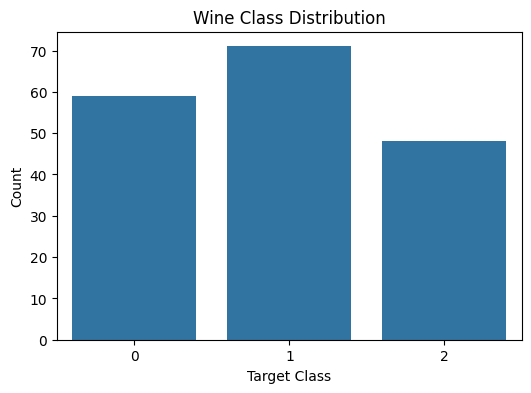

In [188]:
# Wine class distribution
### CODE HERE ###
print("Class distribution : \n", y_wine.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_wine)
plt.title('Wine Class Distribution')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


---Summary statistics---
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.

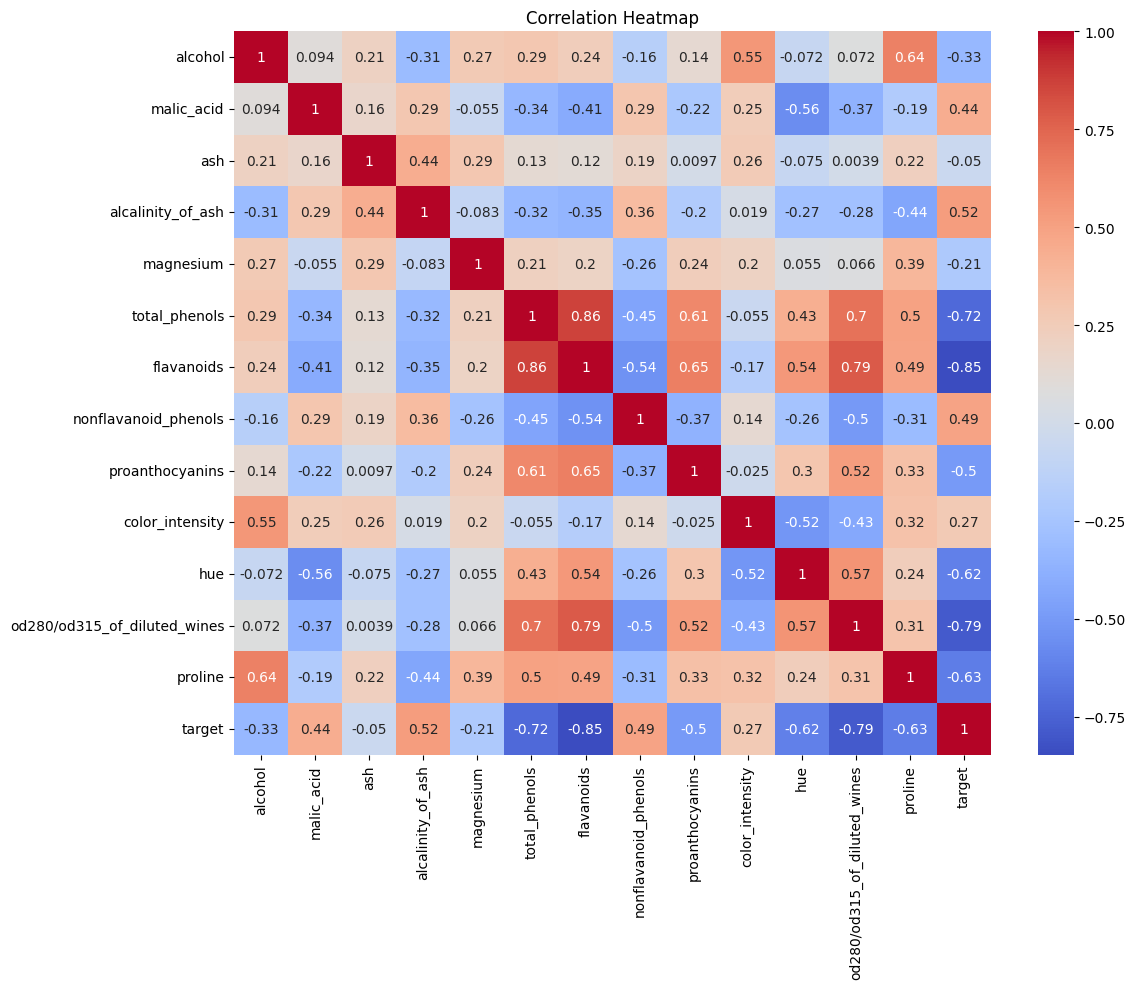

In [189]:
# Summary statistics
### CODE HERE ###
print("---Summary statistics---")
print(df_wine.describe())
# Correlation heatmap
### CODE HERE ###
plt.figure(figsize=(12,10))
sns.heatmap(df_wine.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [190]:
# Stratified train-test split
### CODE HERE ###
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine)



In [191]:
# Scale features: fit on train, transform both
### CODE HERE ###
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)



### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [192]:
# Verify preparation
### CODE HERE ###
print("X_train_scaled shape:", X_train_wine_scaled.shape)
print("X_test_scaled shape:", X_test_wine_scaled.shape)
print("y_train shape:", y_train_wine.shape)
print("y_test shape:", y_test_wine.shape)

print("y_train class distribution:\n", y_train_wine.value_counts())
print("y_test class distribution:\n", y_test_wine.value_counts())

X_train_scaled shape: (124, 13)
X_test_scaled shape: (54, 13)
y_train shape: (124,)
y_test shape: (54,)
y_train class distribution:
 target
1    50
0    41
2    33
Name: count, dtype: int64
y_test class distribution:
 target
1    21
0    18
2    15
Name: count, dtype: int64


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [193]:
# Logistic Regression for Wine
### CODE HERE ###
lr_wine = LogisticRegression( max_iter=1000, random_state=42)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(lr_wine, param_grid_lr, cv=5, scoring='f1_macro')
grid_lr.fit(X_train_wine_scaled, y_train_wine)
best_lr_wine = grid_lr.best_estimator_
y_pred_lr_wine = best_lr_wine.predict(X_test_wine_scaled)
evaluate_model(y_test_wine, y_pred_lr_wine)

print("Logistic Regression Best parameters:", grid_lr.best_params_)
print("Logistic Regression Best CV F1 Score:", grid_lr.best_score_)

Accuracy: 1.0000
Recall: 1.0000
Precision: 1.0000
F1 Score: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Logistic Regression Best parameters: {'C': 0.1}
Logistic Regression Best CV F1 Score: 0.9834098065677013


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [194]:
# KNN for Wine
### CODE HERE ###
knn_wine = KNeighborsClassifier()
param_grid_knn_wine = {
    'n_neighbors': [3, 5, 7, 9,11],
    'weights': ['uniform', 'distance']
}

grid_search_knn_wine = GridSearchCV(estimator=knn_wine, param_grid=param_grid_knn_wine, cv=5, scoring='f1_macro')
grid_search_knn_wine.fit(X_train_wine_scaled, y_train_wine)

print("KNN Best parameters:", grid_search_knn_wine.best_params_)
print("KNN Best CV F1 Score:", grid_search_knn_wine.best_score_)

best_knn_wine = grid_search_knn_wine.best_estimator_
y_pred_knn_wine = best_knn_wine.predict(X_test_wine_scaled)
evaluate_model(y_test_wine, y_pred_knn_wine)
print('=' * 60)

KNN Best parameters: {'n_neighbors': 11, 'weights': 'uniform'}
KNN Best CV F1 Score: 0.9775988992088063
Accuracy: 0.9630
Recall: 0.9683
Precision: 0.9608
F1 Score: 0.9625

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.90      0.95        21
           2       0.88      1.00      0.94        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [195]:
# Decision Tree for Wine
### CODE HERE ###
dt_wine = DecisionTreeClassifier(random_state=42)

param_grid_dt_wine = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt_wine = GridSearchCV(estimator=dt_wine, param_grid=param_grid_dt_wine, cv=5, scoring='f1_macro')
grid_search_dt_wine.fit(X_train_wine_scaled, y_train_wine)

print("Decision Tree Best parameters:", grid_search_dt_wine.best_params_)
print("Decision Tree Best CV F1 Score:", grid_search_dt_wine.best_score_)

best_dt_wine = grid_search_dt_wine.best_estimator_
y_pred_dt_wine = best_dt_wine.predict(X_test_wine_scaled)
evaluate_model(y_test_wine, y_pred_dt_wine)
print('=' * 60)

Decision Tree Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree Best CV F1 Score: 0.8799972347340768
Accuracy: 0.9630
Recall: 0.9593
Precision: 0.9710
F1 Score: 0.9638

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [196]:
# SVM for Wine
### CODE HERE ###
svm_wine = SVC(random_state=42 , probability=True)

param_grid_svm_wine = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search_svm_wine = GridSearchCV(estimator=svm_wine, param_grid=param_grid_svm_wine, cv=5, scoring='f1_macro')
grid_search_svm_wine.fit(X_train_wine_scaled, y_train_wine)
print("SVM Best parameters:", grid_search_svm_wine.best_params_)
print("SVM Best CV F1 Score:", grid_search_svm_wine.best_score_)

best_svm_wine = grid_search_svm_wine.best_estimator_
y_pred_svm_wine = best_svm_wine.predict(X_test_wine_scaled)

evaluate_model(y_test_wine, y_pred_svm_wine)
print('=' * 60)

SVM Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Best CV F1 Score: 0.992046783625731
Accuracy: 0.9815
Recall: 0.9778
Precision: 0.9848
F1 Score: 0.9808

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [197]:
# MLP for Wine
### CODE HERE ###
mlp_wine = MLPClassifier(random_state=42, max_iter=1000,early_stopping=True)
param_grid_mlp_wine = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_mlp_wine = GridSearchCV(estimator=mlp_wine, param_grid=param_grid_mlp_wine, cv=5, scoring='f1_macro')
grid_search_mlp_wine.fit(X_train_wine_scaled, y_train_wine)
print("MLP Best parameters:", grid_search_mlp_wine.best_params_)
print("MLP Best CV F1 Score:", grid_search_mlp_wine.best_score_)


MLP Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
MLP Best CV F1 Score: 0.9136279016646496


In [198]:
# Evaluate MLP on test set
### CODE HERE ###
best_mlp_wine = grid_search_mlp_wine.best_estimator_
y_pred_mlp_wine = best_mlp_wine.predict(X_test_wine_scaled)
evaluate_model(y_test_wine, y_pred_mlp_wine)

Accuracy: 0.8519
Recall: 0.8730
Precision: 0.8720
F1 Score: 0.8506

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88        18
           1       1.00      0.62      0.76        21
           2       0.83      1.00      0.91        15

    accuracy                           0.85        54
   macro avg       0.87      0.87      0.85        54
weighted avg       0.88      0.85      0.84        54



### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [199]:
# Comparison table for all 5 wine models
### CODE HERE ###
model_predictions_wine = {
    "LogisticRegression" : y_pred_lr_wine,
    "KNN" : y_pred_knn_wine,
    "DecisionTree" : y_pred_dt_wine,
    "SVM" : y_pred_svm_wine,
    "MLP" : y_pred_mlp_wine
}

comparison_data_wine = []
for model_name, y_pred in model_predictions_wine.items():
    accuracy = accuracy_score(y_test_wine, y_pred)
    recall = recall_score(y_test_wine, y_pred, average='macro')
    precision = precision_score(y_test_wine, y_pred, average='macro')
    f1 = f1_score(y_test_wine, y_pred, average='macro')

    comparison_data_wine.append({
        "Model": model_name,
        "Accuracy": round(accuracy,4),
        "Macro Precision": round(precision,4),
        "Macro Recall": round(recall,4),
        "MacroF1 Score": round(f1,4),

    })

comparison_df_wine = pd.DataFrame(comparison_data_wine)
comparison_df_wine = comparison_df_wine.set_index('Model')
print(comparison_df_wine)

                    Accuracy  Macro Precision  Macro Recall  MacroF1 Score
Model                                                                     
LogisticRegression    1.0000           1.0000        1.0000         1.0000
KNN                   0.9630           0.9608        0.9683         0.9625
DecisionTree          0.9630           0.9710        0.9593         0.9638
SVM                   0.9815           0.9848        0.9778         0.9808
MLP                   0.8519           0.8720        0.8730         0.8506


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


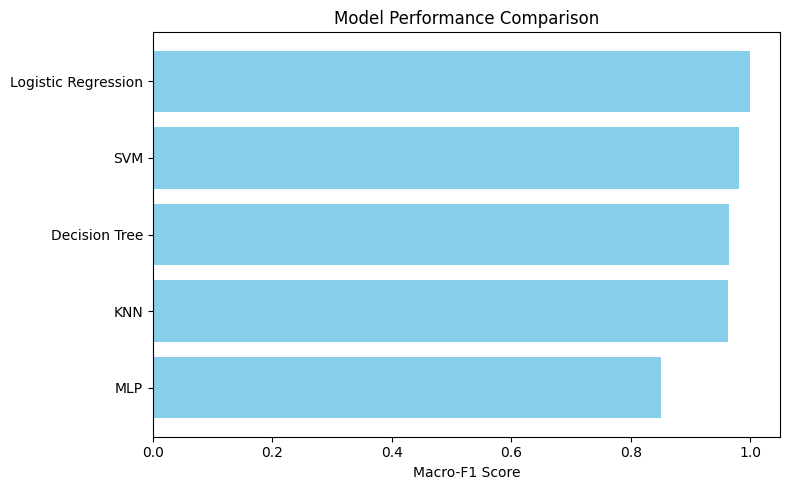

In [200]:
# Macro-F1 bar chart
### CODE HERE ###
models = ["Logistic Regression", "KNN", "Decision Tree", "SVM", "MLP"]
f1_scores = [1.0000, 0.9625, 0.9638, 0.9808, 0.8506]

sorted_indices = np.argsort(f1_scores)
sorted_models = [models[i] for i in sorted_indices]
sorted_f1_scores = [f1_scores[i] for i in sorted_indices]

plt.figure(figsize=(8,5))
plt.barh(sorted_models, sorted_f1_scores, color='skyblue')
plt.xlabel('Macro-F1 Score')
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [201]:
# Cross-validation stability for all 5 wine models
### CODE HERE ###
models_wine = {
    "Logistic Regression": best_lr_wine,
    "KNN": best_knn_wine,
    "Decision Tree": best_dt_wine,
    "SVM": best_svm_wine,
    "MLP": best_mlp_wine
}

cv_results_wine = {}
for model_name, model in models_wine.items():
    scores = cross_val_score(model, X_train_wine_scaled, y_train_wine, cv=5, scoring='f1_macro')
    cv_results_wine[model_name] = {
        "Mean": scores.mean(),
        "Std Dev": scores.std()
    }
    print(f"{model_name} CV Macro-F1: Mean={scores.mean():.4f}, Std Dev={scores.std():.4f}")
    print("-"*35)

Logistic Regression CV Macro-F1: Mean=0.9834, Std Dev=0.0203
-----------------------------------
KNN CV Macro-F1: Mean=0.9776, Std Dev=0.0184
-----------------------------------
Decision Tree CV Macro-F1: Mean=0.8800, Std Dev=0.0772
-----------------------------------
SVM CV Macro-F1: Mean=0.9920, Std Dev=0.0159
-----------------------------------
MLP CV Macro-F1: Mean=0.9136, Std Dev=0.0591
-----------------------------------


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. Logistic regression performed better with score 1.0 

2. Its a small margin  

3. Dataefficiency and overfitting


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. Logistic regression - Macro-F1 score : 1.0

2. Logistic regression

3. 



### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [202]:
# Overfitting study: 3 Decision Tree variants
### CODE HERE ###
variants = [("max_depth=1", DecisionTreeClassifier(max_depth=1, random_state=42)),
             ("max_depth=None", DecisionTreeClassifier(max_depth=None, random_state=42)),
             ("Tuned tree", grid_search_dt_wine.best_estimator_)]

for name, model in variants:
    model.fit(X_train_wine_scaled, y_train_wine)
    y_train_pred = model.predict(X_train_wine_scaled)
    y_test_pred = model.predict(X_test_wine_scaled)

    train_accuracy = accuracy_score(y_train_wine, y_train_pred)
    test_accuracy = accuracy_score(y_test_wine, y_test_pred)
    gap= train_accuracy - test_accuracy

    print(f"{name} - Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}, Gap: {gap:.4f}")
    print("-"*50)

max_depth=1 - Train Accuracy: 0.6613, Test Accuracy: 0.6111, Gap: 0.0502
--------------------------------------------------
max_depth=None - Train Accuracy: 1.0000, Test Accuracy: 0.9630, Gap: 0.0370
--------------------------------------------------
Tuned tree - Train Accuracy: 0.9919, Test Accuracy: 0.9630, Gap: 0.0290
--------------------------------------------------


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy? 

2. Which variant overfits? What is the gap between train and test accuracy?

3. How does the tuned model sit between these two extremes?



*Write your answers here:*

1. Variant "max_depth" =1 underfits . low traing and test accuracy indicates that it is underfitting 

2. max_depth=None overfits bacause model achieves train accuracy of 1.0000 . Gap is 0.0370 

3. This has balanced results as train and test accuracy is high and gap is narrow which represents balance between variance and bias


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
